<a href="https://colab.research.google.com/github/noelivander/BD-2/blob/main/prepare_data_IndonesiaGelap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mengimport & menampilkan file csv yang hendak di bersihkan

In [6]:
import pandas as pd

IndonesiaGelap = pd.read_csv('IndonesiaGelap.csv')
print(IndonesiaGelap.head())

   conversation_id_str                      created_at  favorite_count  \
0  1903812706395910425  Sun Mar 23 14:14:54 +0000 2025           10642   
1  1902566757228859658  Thu Mar 20 03:43:57 +0000 2025           68351   
2  1903299460157018468  Sat Mar 22 04:15:27 +0000 2025           50654   
3  1904025845322403887  Mon Mar 24 04:21:51 +0000 2025           30738   
4  1902963237597159474  Fri Mar 21 05:59:25 +0000 2025           53524   

                                           full_text               id_str  \
0  Saya menyaksikan dengan mata kepala saya sendi...  1903812706395910425   
1   Gass #TolakRUUTNI #IndonesiaGelap https://t.c...  1902566757228859658   
2  Jangan mau kembali ke masa orba lagi! TOLAK!! ...  1903299460157018468   
3            #IndonesiaGelap https://t.co/M5InyVehTB  1904025845322403887   
4  Jamuan hangat untuk para pengkhianat rakyat. #...  1902963237597159474   

                                         image_url in_reply_to_screen_name  \
0  https://pbs

Menampilkan struktur kolom dari data tersebut

In [7]:
IndonesiaGelap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      204 non-null    int64 
 1   created_at               204 non-null    object
 2   favorite_count           204 non-null    int64 
 3   full_text                204 non-null    object
 4   id_str                   204 non-null    int64 
 5   image_url                189 non-null    object
 6   in_reply_to_screen_name  2 non-null      object
 7   lang                     204 non-null    object
 8   location                 147 non-null    object
 9   quote_count              204 non-null    int64 
 10  reply_count              204 non-null    int64 
 11  retweet_count            204 non-null    int64 
 12  tweet_url                204 non-null    object
 13  user_id_str              204 non-null    int64 
 14  username                 204 non-null    o

**Tahapan Cleaning Data**

Menampilkan isi kolom full_text yang berisi cuitan2 masyarakat

In [8]:
IndonesiaGelap["full_text"]

,full_text
0,Saya menyaksikan dengan mata kepala saya sendi...
1,Gass #TolakRUUTNI #IndonesiaGelap https://t.c...
2,Jangan mau kembali ke masa orba lagi! TOLAK!! ...
3,#IndonesiaGelap https://t.co/M5InyVehTB
4,Jamuan hangat untuk para pengkhianat rakyat. #...
...,...
199,kita rakyat punya hak bersuara please don't ig...
200,[Delsoon] Wkwkkw para artist bilaik : : Gambar...
201,Malang membara.. #TolakRUUTNI #TolakRevisiUUTN...
202,JANGAN KAO BUAT KU MENJADI IBLISSS MURKA AKU N...


Sebuah fungsi cleaning untuk membersihkan simbol-simbol yang tidak penting/tak digunakan

In [9]:
#membuat function cleaning

import re
def clean(s):
    s = s.replace(r'<lb>', "\n")
    s = s.replace(r'<tab>', "\i")
    s = re.sub(r'<br */*>', "\n", s)
    s = s.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    s = s.replace("&amp;", "&")
    # markdown urls
    s = re.sub(r'\(https*://[^\)]*\)', "", s)
    # normal urls
    s = re.sub(r'https*://[^\s]*', "", s)
    s = re.sub(r'_+', ' ', s)
    s = re.sub(r'"+', '"', s)
    return str(s)

Menyimpan hasilnya dalam sebuah variabel yang baru

In [10]:
IndonesiaGelap["text_clean"] = ''

In [11]:
for i, row in IndonesiaGelap.iterrows():
    IndonesiaGelap.at[i, "text_clean"] = clean(row.full_text)

Menampilkan 5 data teratas

In [12]:
IndonesiaGelap.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,text_clean
0,1903812706395910425,Sun Mar 23 14:14:54 +0000 2025,10642,Saya menyaksikan dengan mata kepala saya sendi...,1903812706395910425,https://pbs.twimg.com/media/Gmuzg7HbMAA5oyk.jpg,NaN,in,spain,130,710,7591,https://x.com/seupurane/status/190381270639591...,1347551996924973056,seupurane,Saya menyaksikan dengan mata kepala saya sendi...
1,1902566757228859658,Thu Mar 20 03:43:57 +0000 2025,68351,Gass #TolakRUUTNI #IndonesiaGelap https://t.c...,1902566757228859658,https://pbs.twimg.com/media/GmdGYUua8AMgQ8f.jpg,NaN,en,Markas efpiay Petamburan JKT,267,347,21724,https://x.com/Opposite6888/status/190256675722...,424908793,Opposite6888,Gass #TolakRUUTNI #IndonesiaGelap
2,1903299460157018468,Sat Mar 22 04:15:27 +0000 2025,50654,Jangan mau kembali ke masa orba lagi! TOLAK!! ...,1903299460157018468,https://pbs.twimg.com/media/GmngxTxaEAIwoSA.jpg,NaN,in,my bedroom,179,1839,27732,https://x.com/neverxended/status/1903299460157...,1237296136659931136,neverxended,Jangan mau kembali ke masa orba lagi! TOLAK!! ...
3,1904025845322403887,Mon Mar 24 04:21:51 +0000 2025,30738,#IndonesiaGelap https://t.co/M5InyVehTB,1904025845322403887,https://pbs.twimg.com/media/Gmx1Zx_bMAAuM3Q.jpg,NaN,qme,Indonesia,50,139,11131,https://x.com/_Jerung27/status/190402584532240...,1183286254126780417,_Jerung27,#IndonesiaGelap
4,1902963237597159474,Fri Mar 21 05:59:25 +0000 2025,53524,Jamuan hangat untuk para pengkhianat rakyat. #...,1902963237597159474,https://pbs.twimg.com/media/Gmiu-qObwAA33OY.jpg,NaN,in,NaN,365,1079,26810,https://x.com/caracaltamer/status/190296323759...,1242287027007016962,caracaltamer,Jamuan hangat untuk para pengkhianat rakyat. #...


Membandingkan data sebelum di clean dan setelah di clean

In [13]:
IndonesiaGelap[["full_text", "text_clean"]].head()

,full_text,text_clean
0,Saya menyaksikan dengan mata kepala saya sendi...,Saya menyaksikan dengan mata kepala saya sendi...
1,Gass #TolakRUUTNI #IndonesiaGelap https://t.c...,Gass #TolakRUUTNI #IndonesiaGelap
2,Jangan mau kembali ke masa orba lagi! TOLAK!! ...,Jangan mau kembali ke masa orba lagi! TOLAK!! ...
3,#IndonesiaGelap https://t.co/M5InyVehTB,#IndonesiaGelap
4,Jamuan hangat untuk para pengkhianat rakyat. #...,Jamuan hangat untuk para pengkhianat rakyat. #...


NLTK Process

Menginstal Natural Language Toolkit

In [ ]:
pip install nltk

mengunduh dataset

In [14]:
#tokenisasi
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize,word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Contoh proses tokenisasi dalam bahasa inggris

In [15]:
example_text = "Hello there, how are you doing today? The weather is great today. The sky is blue. python is awsome"
print(sent_tokenize(example_text))
print(word_tokenize(example_text))

['Hello there, how are you doing today?', 'The weather is great today.', 'The sky is blue.', 'python is awsome']
['Hello', 'there', ',', 'how', 'are', 'you', 'doing', 'today', '?', 'The', 'weather', 'is', 'great', 'today', '.', 'The', 'sky', 'is', 'blue', '.', 'python', 'is', 'awsome']


melakukan tokenisasi pada data yang telah di clean & membandingkan data sebelum di tokenisasi dan setelah di tokenisasi

In [16]:
# Tokenisasi kata pada kolom 'text_clean'
IndonesiaGelap['tokenized_text'] = IndonesiaGelap['text_clean'].apply(lambda x: word_tokenize(x))

# Menampilkan beberapa baris pertama data dengan kolom tokenized_text
print(IndonesiaGelap[['text_clean', 'tokenized_text']].head())


                                          text_clean  \
0  Saya menyaksikan dengan mata kepala saya sendi...   
1                 Gass #TolakRUUTNI #IndonesiaGelap    
2  Jangan mau kembali ke masa orba lagi! TOLAK!! ...   
3                                   #IndonesiaGelap    
4  Jamuan hangat untuk para pengkhianat rakyat. #...   

                                      tokenized_text  
0  [Saya, menyaksikan, dengan, mata, kepala, saya...  
1          [Gass, #, TolakRUUTNI, #, IndonesiaGelap]  
2  [Jangan, mau, kembali, ke, masa, orba, lagi, !...  
3                                [#, IndonesiaGelap]  
4  [Jamuan, hangat, untuk, para, pengkhianat, rak...  


Menampilkan 5 data teratas setelah tokenisasi

In [17]:
IndonesiaGelap["tokenized_text"].head()

,tokenized_text
0,"[Saya, menyaksikan, dengan, mata, kepala, saya..."
1,"[Gass, #, TolakRUUTNI, #, IndonesiaGelap]"
2,"[Jangan, mau, kembali, ke, masa, orba, lagi, !..."
3,"[#, IndonesiaGelap]"
4,"[Jamuan, hangat, untuk, para, pengkhianat, rak..."


Mengimport stopwords yang ada dalam bahasa indonesia

In [18]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words_indonesia = stopwords.words('indonesian')

stop_words_indonesia

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['ada',
 'adalah',
 'adanya',
 'adapun',
 'agak',
 'agaknya',
 'agar',
 'akan',
 'akankah',
 'akhir',
 'akhiri',
 'akhirnya',
 'aku',
 'akulah',
 'amat',
 'amatlah',
 'anda',
 'andalah',
 'antar',
 'antara',
 'antaranya',
 'apa',
 'apaan',
 'apabila',
 'apakah',
 'apalagi',
 'apatah',
 'artinya',
 'asal',
 'asalkan',
 'atas',
 'atau',
 'ataukah',
 'ataupun',
 'awal',
 'awalnya',
 'bagai',
 'bagaikan',
 'bagaimana',
 'bagaimanakah',
 'bagaimanapun',
 'bagi',
 'bagian',
 'bahkan',
 'bahwa',
 'bahwasanya',
 'baik',
 'bakal',
 'bakalan',
 'balik',
 'banyak',
 'bapak',
 'baru',
 'bawah',
 'beberapa',
 'begini',
 'beginian',
 'beginikah',
 'beginilah',
 'begitu',
 'begitukah',
 'begitulah',
 'begitupun',
 'bekerja',
 'belakang',
 'belakangan',
 'belum',
 'belumlah',
 'benar',
 'benarkah',
 'benarlah',
 'berada',
 'berakhir',
 'berakhirlah',
 'berakhirnya',
 'berapa',
 'berapakah',
 'berapalah',
 'berapapun',
 'berarti',
 'berawal',
 'berbagai',
 'berdatangan',
 'beri',
 'berikan',
 'berikut'

Contoh penerapan stopwords dalam bahasa inggris

In [19]:
from nltk.corpus import stopwords
text = 'he is a good boy. he is very good in coding'
text = word_tokenize(text)
text_with_no_stopwords = [word for word in text if word not in stopwords.words('english')]
text_with_no_stopwords

['good', 'boy', '.', 'good', 'coding']

Mengambil stopwords Indonesia, lalu menerapkan fungsi remove stopwords ke data yang telah di tokenisasi sebelumnya dan menampilkan hasilnya.

In [20]:
stop_words_indonesia = stopwords.words('indonesian')

def remove_stopwords(token_list):
  return [word for word in token_list if word.lower() not in stop_words_indonesia]

IndonesiaGelap['tokenized_stopwords'] = IndonesiaGelap['tokenized_text'].apply(remove_stopwords)

IndonesiaGelap[['tokenized_text', 'tokenized_stopwords']].head()

,tokenized_text,tokenized_stopwords
0,"[Saya, menyaksikan, dengan, mata, kepala, saya...","[menyaksikan, mata, kepala, PEMUKULAN, APARAT,..."
1,"[Gass, #, TolakRUUTNI, #, IndonesiaGelap]","[Gass, #, TolakRUUTNI, #, IndonesiaGelap]"
2,"[Jangan, mau, kembali, ke, masa, orba, lagi, !...","[orba, !, TOLAK, !, !, #, TolakRUUTNI, #, Tola..."
3,"[#, IndonesiaGelap]","[#, IndonesiaGelap]"
4,"[Jamuan, hangat, untuk, para, pengkhianat, rak...","[Jamuan, hangat, pengkhianat, rakyat, ., #, To..."


Contoh penerapan stemming

In [21]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()    ## Creating an object for porterstemmer
example_words = ['earn',"earning","earned","earns"]  ##Example words
for w in example_words:
    print(ps.stem(w))

earn
earn
earn
earn


Menginstal paket yang dibutuhkan

In [24]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.4 MB/s eta 0:00:00


Mengimport paket yang telah diinstal lalu membuat objek stemmer untuk membentuk fungsi steeming yang kemudian akan diterapkan pada data yang telah di stopwords sebelumnya & menampilkan hasilnya.

In [25]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming_sastrawi(token_list):
  return [stemmer.stem(word) for word in token_list]

IndonesiaGelap['stemmed_words'] = IndonesiaGelap['tokenized_stopwords'].apply(stemming_sastrawi)

IndonesiaGelap[['tokenized_stopwords', 'stemmed_words']]

,tokenized_stopwords,stemmed_words
0,"[menyaksikan, mata, kepala, PEMUKULAN, APARAT,...","[saksi, mata, kepala, pukul, aparat, mas, nyel..."
1,"[Gass, #, TolakRUUTNI, #, IndonesiaGelap]","[gass, , tolakruutni, , indonesiagelap]"
2,"[orba, !, TOLAK, !, !, #, TolakRUUTNI, #, Tola...","[orba, , tolak, , , , tolakruutni, , tolakdwif..."
3,"[#, IndonesiaGelap]","[, indonesiagelap]"
4,"[Jamuan, hangat, pengkhianat, rakyat, ., #, To...","[jamu, hangat, khianat, rakyat, , , tolakruutn..."
...,...,...
199,"[rakyat, hak, bersuara, please, do, n't, ignor...","[rakyat, hak, suara, please, do, n t, ignore, ..."
200,"[[, Delsoon, ], Wkwkkw, artist, bilaik, :, :, ...","[, delsoon, , wkwkkw, artist, bilaik, , , gamb..."
201,"[Malang, membara, .., #, TolakRUUTNI, #, Tolak...","[malang, bara, , , tolakruutni, , tolakrevisiu..."
202,"[KAO, KU, IBLISSS, MURKA, NII, #, GagalkanRUUT...","[kao, ku, iblisss, murka, nii, , gagalkanruutn..."


In [1]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.9 MB/s eta 0:00:00


In [26]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Inisialisasi objek SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text_list):
    # Gabungkan list token menjadi satu string
    text = " ".join(text_list)

    # Lakukan analisis sentimen
    scores = analyzer.polarity_scores(text)

    # Kembalikan nilai compound score
    return scores['compound']

# Terapkan fungsi analyze_sentiment ke kolom 'stemmed_words'
IndonesiaGelap['sentiment_score'] = IndonesiaGelap['stemmed_words'].apply(analyze_sentiment)

In [28]:

# Menampilkan beberapa baris pertama data dengan kolom sentiment_score
print(IndonesiaGelap[['stemmed_words', 'sentiment_score']].head())

                                       stemmed_words  sentiment_score
0  [saksi, mata, kepala, pukul, aparat, mas, nyel...              0.0
1            [gass, , tolakruutni, , indonesiagelap]              0.0
2  [orba, , tolak, , , , tolakruutni, , tolakdwif...              0.0
3                                 [, indonesiagelap]              0.0
4  [jamu, hangat, khianat, rakyat, , , tolakruutn...              0.0


In [30]:
# Membuat label setiap komentar

# Fungsi untuk menentukan label sentimen berdasarkan sentiment_score
def label_sentiment(score):
    if score < 0:
        return 'negatif'
    elif score == 0:
        return 'netral'
    else:
        return 'positif'

# Buat kolom baru 'sentiment_label' berdasarkan kolom 'sentiment_score'
IndonesiaGelap['sentiment_label'] = IndonesiaGelap['sentiment_score'].apply(label_sentiment)

# Menampilkan beberapa baris pertama data dengan kolom sentiment_label
print(IndonesiaGelap[['stemmed_words', 'sentiment_score', 'sentiment_label']].head())

                                       stemmed_words  sentiment_score  \
0  [saksi, mata, kepala, pukul, aparat, mas, nyel...              0.0   
1            [gass, , tolakruutni, , indonesiagelap]              0.0   
2  [orba, , tolak, , , , tolakruutni, , tolakdwif...              0.0   
3                                 [, indonesiagelap]              0.0   
4  [jamu, hangat, khianat, rakyat, , , tolakruutn...              0.0   

  sentiment_label  
0          netral  
1          netral  
2          netral  
3          netral  
4          netral  


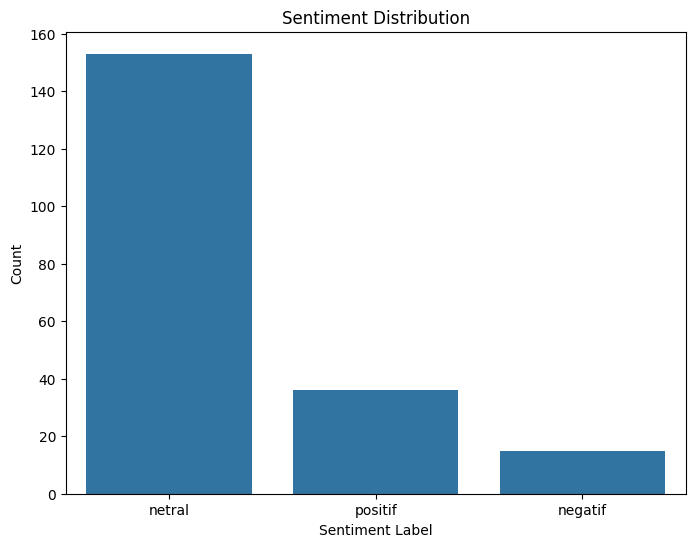

In [32]:
#Membuat grafik plot
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=IndonesiaGelap)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

In [33]:
# prompt: Buat word cloud dari setiap kategori

!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

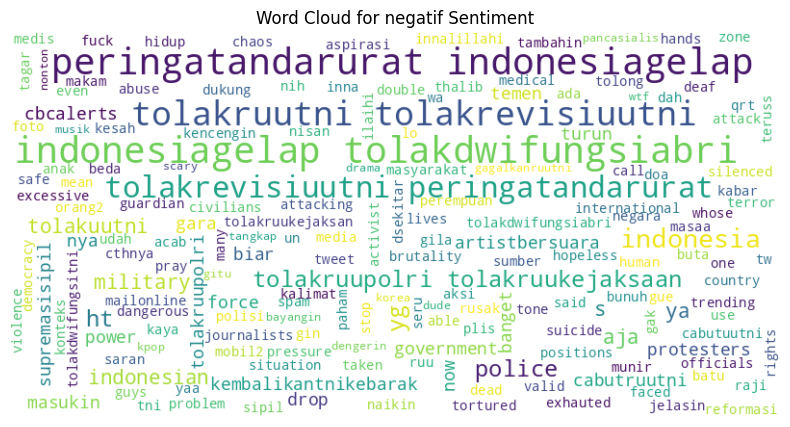

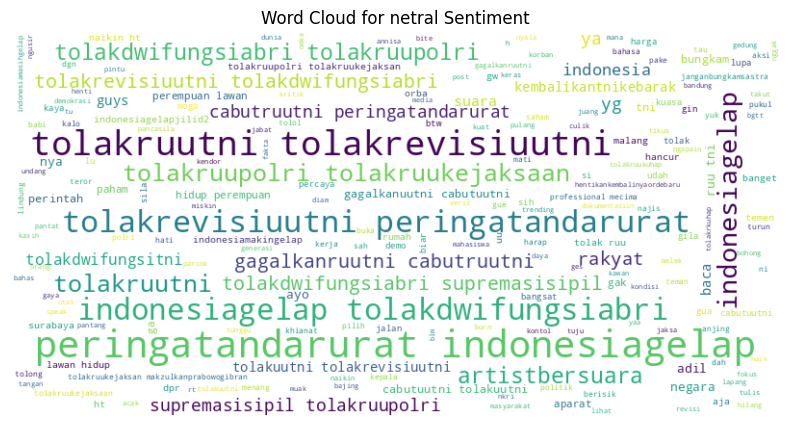

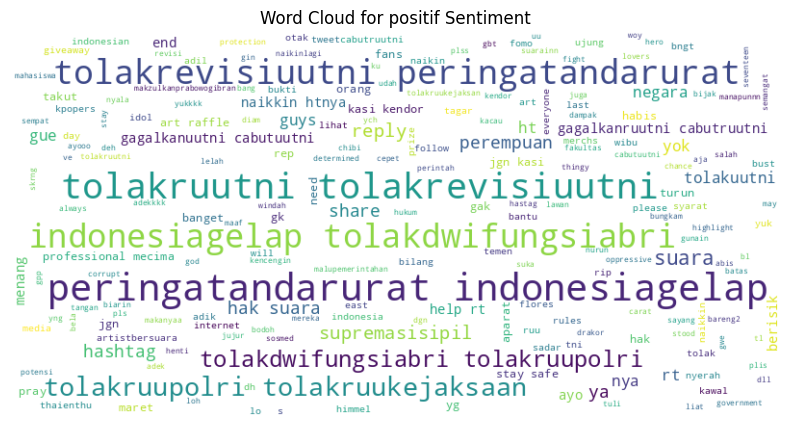

In [35]:
# Group data by sentiment label
sentiment_groups = IndonesiaGelap.groupby('sentiment_label')

# Create word clouds for each sentiment category
for sentiment, group in sentiment_groups:
    # Combine all stemmed words in the group
    all_words = ' '.join([' '.join(words) for words in group['stemmed_words']])

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

    # Display the generated image:
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f'Word Cloud for {sentiment} Sentiment')
    plt.show()
